# DiffBrush — text-to-handwriting

Geef een string mee, kies een writer-id uit `DiffBrush/test_data/`, en genereer een handgeschreven regel.

Charset: ASCII (geen accenten). Max 61 tekens per regel.

In [1]:
import os, sys
DIFFBRUSH_DIR = os.path.abspath('DiffBrush')
if DIFFBRUSH_DIR not in sys.path:
    sys.path.insert(0, DIFFBRUSH_DIR)
os.chdir(DIFFBRUSH_DIR)

import torch, torchvision
from parse_config import cfg, cfg_from_file, assert_and_infer_cfg
from models.unet import UNetModel
from models.diffusion import Diffusion
from diffusers import AutoencoderKL
from data_loader.IAMDataset import IAMGenerateDataset
from utils.util import fix_seed
from generate_custom import WRITER_NUMS, validate

c:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CFG_FILE          = 'configs/IAM.yml'
PRETRAINED_MODEL  = 'model_zoo/DiffBrush-ckpt.pt'
STABLE_DIF_PATH   = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'
SAMPLING_STEPS    = 50
ETA               = 0.0
SAVE_DIR          = 'Generated/custom'
os.makedirs(SAVE_DIR, exist_ok=True)

cfg_from_file(CFG_FILE)
assert_and_infer_cfg()
fix_seed(cfg.TRAIN.SEED)
print('device:', DEVICE)

device: cuda


In [3]:
diffusion = Diffusion(device=DEVICE)

unet = UNetModel(
    in_channels=cfg.MODEL.IN_CHANNELS, model_channels=cfg.MODEL.EMB_DIM,
    out_channels=cfg.MODEL.OUT_CHANNELS, num_res_blocks=cfg.MODEL.NUM_RES_BLOCKS,
    attention_resolutions=(1, 1), channel_mult=(1, 1), num_heads=cfg.MODEL.NUM_HEADS,
    context_dim=cfg.MODEL.EMB_DIM, nb_classes=WRITER_NUMS,
).to(DEVICE)
unet.load_state_dict(torch.load(PRETRAINED_MODEL, map_location='cpu'))
unet.eval()

vae = AutoencoderKL.from_pretrained(STABLE_DIF_PATH, subfolder='vae').to(DEVICE)
vae.requires_grad_(False)

dataset = IAMGenerateDataset(cfg.TEST.STYLE_PATH, 'test', ref_num=1)
available_writers = sorted(set(dataset.author_id))
print(f'Loaded. {len(available_writers)} writers available, e.g. {available_writers[:10]}')

Proxy Anchor Initialization: only real
Proxy Anchor Initialization: only real


C:\Users\karol\AppData\Local\Temp\ipykernel_53808\885683191.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet.load_state_dict(torch.load(PRETRAINED_MODEL, map_locatio

Loaded. 161 writers available, e.g. ['168', '169', '170', '172', '173', '175', '177', '179', '180', '181']


In [ ]:
import numpy as np
from PIL import Image
from IPython.display import display

PAD_TARGET  = 50   # pad short text up to this many chars (trained range 35-61)
CROP_THRESH = 240  # pixel value below this counts as "ink"

def _crop_trailing_whitespace(img: Image.Image, thresh: int = CROP_THRESH, margin: int = 6) -> Image.Image:
    arr = np.asarray(img)
    ink_cols = np.where((arr < thresh).any(axis=0))[0]
    if len(ink_cols) == 0:
        return img
    right = min(arr.shape[1], int(ink_cols.max()) + margin)
    return img.crop((0, 0, right, arr.shape[0]))

def generate(text, writer_id, save=True, pad=True, crop=True):
    raw = text
    if pad and len(text) < PAD_TARGET:
        text = text.ljust(PAD_TARGET)
    validate(text)
    if writer_id not in available_writers:
        raise ValueError(f'unknown writer {writer_id}; try {available_writers[:10]}')
    style_np, style_idx = dataset.get_style_ref(writer_id)
    style_ref = torch.from_numpy(style_np).unsqueeze(0).unsqueeze(0).to(torch.float32).to(DEVICE)
    text_ref = dataset.get_content(text).to(DEVICE)
    x = torch.randn((1, 4, style_ref.shape[2] // 8, dataset.fixed_len // 8)).to(DEVICE)
    with torch.no_grad():
        imgs = diffusion.ddim_sample(unet, vae, 1, x, style_ref, text_ref, SAMPLING_STEPS, ETA)
    img = torchvision.transforms.ToPILImage()(imgs[0]).convert('L')
    if crop:
        img = _crop_trailing_whitespace(img)
    if save:
        safe = ''.join(c if c.isalnum() else '_' for c in raw)[:40]
        out = os.path.join(SAVE_DIR, f'{writer_id}-{safe}_{style_idx}.png')
        img.save(out)
        print('saved:', out)
    return img

saved: Generated/custom\168-Paleisplein_12_c04-110-02.png


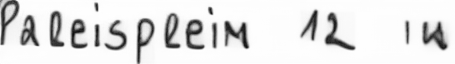

In [13]:
img = generate('Paleisplein 12', writer_id=available_writers[0])
display(img)

len = 42
saved: Generated/custom\168-Koningin_Julianaplein_10__2595_AA_Den_Ha_c04-116-03.png


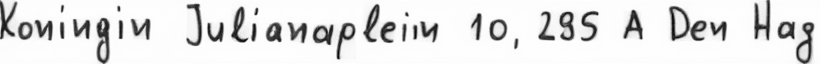

In [14]:
# Full address line — naturally in the 35-61 char trained regime, no padding needed.
addr = 'Koningin Julianaplein 10, 2595 AA Den Haag'  # 42 chars
print(f'len = {len(addr)}')
img = generate(addr, writer_id=available_writers[0])
display(img)

In [15]:
# Load TrOCR for content-accuracy scoring (handwritten line model).
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

TROCR_NAME = 'microsoft/trocr-base-handwritten'
trocr_proc  = TrOCRProcessor.from_pretrained(TROCR_NAME)
trocr_model = VisionEncoderDecoderModel.from_pretrained(TROCR_NAME).to(DEVICE).eval()

def trocr_read(img: Image.Image) -> str:
    pixel_values = trocr_proc(images=img.convert('RGB'), return_tensors='pt').pixel_values.to(DEVICE)
    with torch.no_grad():
        ids = trocr_model.generate(pixel_values, max_new_tokens=64)
    return trocr_proc.batch_decode(ids, skip_special_tokens=True)[0]

def _levenshtein(a: str, b: str) -> int:
    if len(a) < len(b): a, b = b, a
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(cur[-1] + 1, prev[j] + 1, prev[j-1] + (ca != cb)))
        prev = cur
    return prev[-1]

def cer(pred: str, target: str) -> float:
    return _levenshtein(pred.strip(), target.strip()) / max(1, len(target.strip()))

print('TrOCR ready')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TrOCR ready


  [0] CER=0.238  ->  'Koningin Julianstein 10 , 23933 A Den Hazy'
  [1] CER=0.190  ->  'Koningin Julianstein 10,289S A Den Hoag'
  [2] CER=0.262  ->  'Koning in Indianapolis 10 , 2598 A Den Haug'
  [3] CER=0.333  ->  'Koning in Indianapolis in 10 2388 A Den Hag'
  [4] CER=0.119  ->  'Koningin Juhanaplein 10 2598 A Den Haag'
  [5] CER=0.119  ->  'Koning in Julianallein 10, 2999 A Den Haag'
best: CER=0.119  'Koningin Juhanaplein 10 2598 A Den Haag'
saved: Generated/custom\170-Koningin_Julianaplein_10__2595_AA_Den_Ha_best.png


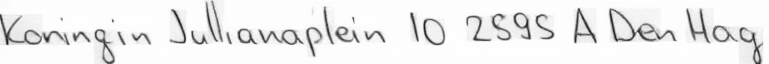

In [19]:
# Best-of-N: generate several candidates with different seeds, keep the one TrOCR reads closest to target.
def generate_best_of_n(text, writer_id, n=6, save=True, verbose=True):
    candidates = []
    for i in range(n):
        torch.manual_seed(int(torch.randint(0, 2**31 - 1, (1,)).item()))
        img = generate(text, writer_id, save=False)
        pred = trocr_read(img)
        score = cer(pred, text)
        candidates.append((score, pred, img))
        if verbose:
            print(f'  [{i}] CER={score:.3f}  ->  {pred!r}')
    candidates.sort(key=lambda t: t[0])
    best_score, best_pred, best_img = candidates[0]
    if verbose:
        print(f'best: CER={best_score:.3f}  {best_pred!r}')
    if save:
        safe = ''.join(c if c.isalnum() else '_' for c in text)[:40]
        out = os.path.join(SAVE_DIR, f'{writer_id}-{safe}_best.png')
        best_img.save(out)
        print('saved:', out)
    return best_img, best_score, best_pred

addr = 'Koningin Julianaplein 10, 2595 AA Den Haag'
img, score, pred = generate_best_of_n(addr, available_writers[2], n=6)
display(img)

saved: Generated/custom\168-Hello_world_c04-110-01.png


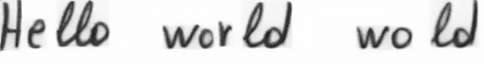

saved: Generated/custom\168-Prime_Vision_c04-116-02.png


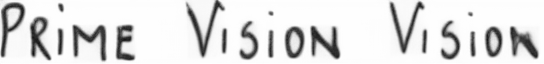

saved: Generated/custom\168-Den_Haag_2511_c04-110-01.png


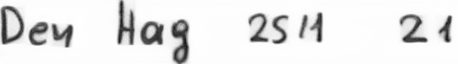

saved: Generated/custom\169-Hello_world_c04-134-05.png


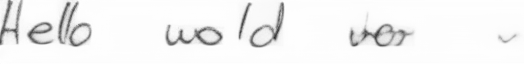

saved: Generated/custom\169-Prime_Vision_c04-134-02.png


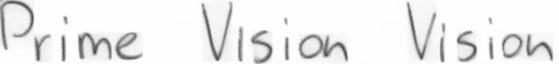

saved: Generated/custom\169-Den_Haag_2511_c04-134-02.png


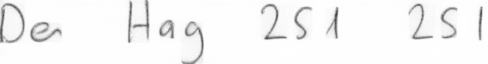

saved: Generated/custom\170-Hello_world_c04-144-06.png


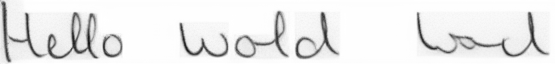

saved: Generated/custom\170-Prime_Vision_c04-150-04.png


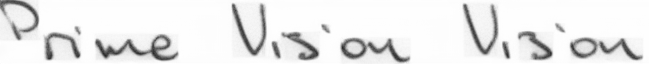

saved: Generated/custom\170-Den_Haag_2511_c04-144-05.png


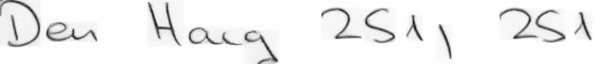

In [17]:
texts   = ['Hello world', 'Prime Vision', 'Den Haag 2511']
writers = available_writers[:3]
for w in writers:
    for t in texts:
        display(generate(t, w))